# LeNet-5 com PyTorch
Aqui está a implementação da arquitetura original da LeNet-5 adaptada para MaxPool e ReLU, sem adicionar código de treinamento no momento.

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LeNet5(nn.Module):
    def __init__(self, num_classes=10):
        super(LeNet5, self).__init__()
        
        # Camadas convolucionais
        # Padding=2 é usado na primeira camada para que uma imagem de entrada 28x28 (tipo MNIST) 
        # seja convertida para 32x32 implicitamente antes da convolução.
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1, padding=2)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1)
        self.conv3 = nn.Conv2d(in_channels=16, out_channels=120, kernel_size=5, stride=1)
        
        # Camadas lineares (Fully Connected)
        self.fc1 = nn.Linear(in_features=120, out_features=84)
        self.fc2 = nn.Linear(in_features=84, out_features=num_classes)
        
    def forward(self, x):
        # C1 -> ReLU -> S2 (MaxPool)
        x = F.max_pool2d(F.relu(self.conv1(x)), kernel_size=2, stride=2)
        
        # C3 -> ReLU -> S4 (MaxPool)
        x = F.max_pool2d(F.relu(self.conv2(x)), kernel_size=2, stride=2)
        
        # C5 -> ReLU
        x = F.relu(self.conv3(x))
        
        # Flatten (achatar) para as camadas Fully Connected
        x = torch.flatten(x, 1) # Mantém a dimensão do batch (dim=0)
        
        # F6 -> ReLU
        x = F.relu(self.fc1(x))
        
        # Output (Camada final sem ativação explícita pois tipicamente usa-se CrossEntropyLoss por fora)
        x = self.fc2(x)
        
        return x

# Instanciando o modelo para checagem
model = LeNet5()
print(model)

LeNet5(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (conv3): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=120, out_features=84, bias=True)
  (fc2): Linear(in_features=84, out_features=10, bias=True)
)


--- 
### Visualizando os filtros antes do treinamento
No PyTorch, as camadas `Conv2d` têm seus pesos (filtros) inicializados aleatoriamente no momento da instanciação. Como nossa primeira camada (`conv1`) possui exatamente **6 filtros** e cada um tem dimensões `5x5` para *1 canal* de entrada, é perfeitamente possível desenhar a "imagem" de cada filtro.

Formato do tensor dos filtros conv1: torch.Size([6, 1, 5, 5])


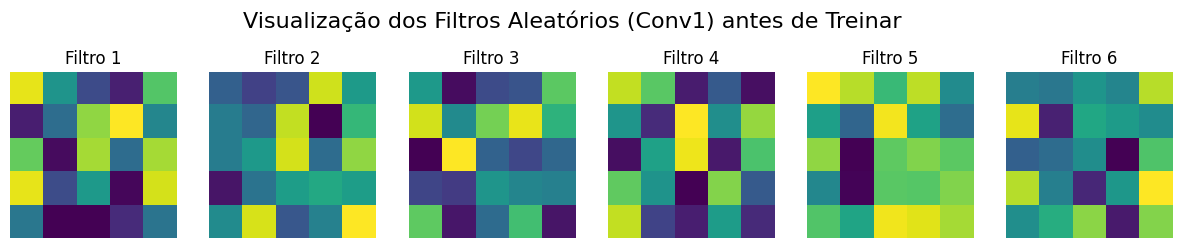

In [19]:
import matplotlib.pyplot as plt

# 1. Instanciamos o modelo para garantir que ele existe na memória
model = LeNet5(num_classes=10)

# 2. Extraímos os pesos da camada conv1. O 'detach().cpu()' garante 
# que não estamos pegando do fluxo de gradientes, isolando o tensor original num formato puramente numérico ou cópia na CPU
filters = model.conv1.weight.detach().cpu()

# A estrutura e shape do tensor é [out_channels, in_channels, kernel_height, kernel_width] -> [6, 1, 5, 5]
print(f'Formato do tensor dos filtros conv1: {filters.shape}')

fig, axs = plt.subplots(1, 6, figsize=(15, 3))
fig.suptitle('Visualização dos Filtros Aleatórios (Conv1) antes de Treinar', fontsize=16)

for i in range(6):
    # Coletamos o filtro i do primeiro (único) canal de entrada 
    f = filters[i, 0]
    
    # Desenhamos como imagem numa escala de cor
    axs[i].imshow(f, cmap='viridis')
    axs[i].axis('off')
    axs[i].set_title(f'Filtro {i+1}')

plt.show()

--- 
### Importando o Dataset MNIST
Vamos fazer o download e carregar os dados de treinamento num `DataLoader`. Em seguida, usaremos o matplotlib para exibir algumas instâncias.

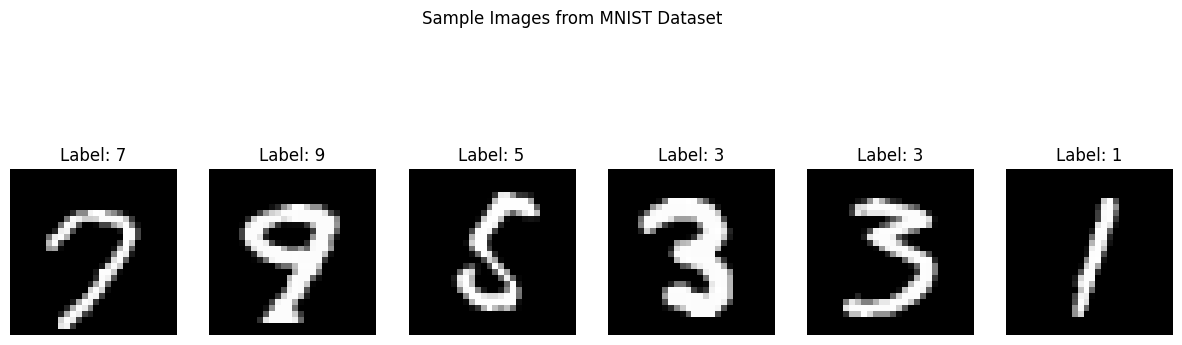

In [16]:

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=6, shuffle=True)

dataiter = iter(train_loader)
images, labels = next(dataiter)

fig, axes = plt.subplots(1, 6, figsize=(15, 5))
for i, ax in enumerate(axes):
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(f'Label: {labels[i].item()}')
    ax.axis('off')

plt.suptitle('Sample Images from MNIST Dataset')
plt.show()

---
### Saída da Primeira Camada (Feature Maps)
Podemos visualizar o que exatamente a primeira camada convolucional aprendeu a "enxergar" após treinada. Ao passar a imagem, a camada gera 6 filtros (mapas de características).

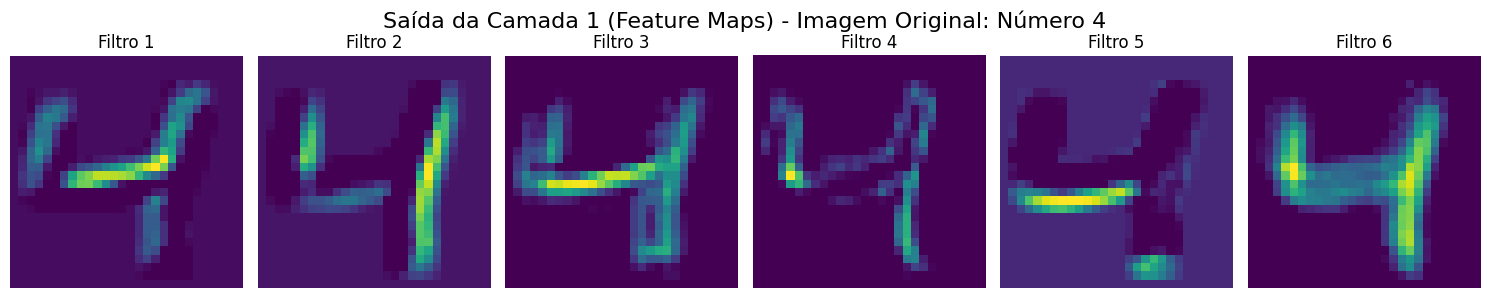

In [18]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

# 1. Pegando a MESMA imagem específica que o professor usou (índice 2)
sample_image, sample_label = train_dataset[2]

# Adiciona a dimensão do batch (fica 1, 1, 28, 28) e transfere para o hardware correto
img = sample_image.unsqueeze(0).to(device)

# 2. Faz a inferência apenas passando pela primeira camada usando a variável 'model'
with torch.no_grad():
    out_conv1 = model.conv1(img)
    out_relu1 = F.relu(out_conv1)

# O tensor sai com shape [1, 6, 28, 28]. 
# Usamos o squeeze(0) para remover a dimensão de batch e mandamos pra CPU para poder desenhar.
feature_maps = out_relu1.squeeze(0).cpu().numpy()

# Desenhando na tela as saídas dos filtros da camada 1
fig, axs = plt.subplots(1, 6, figsize=(15, 3))
fig.suptitle(f"Saída da Camada 1 (Feature Maps) - Imagem Original: Número {sample_label}", fontsize=16)

for i in range(6):
    axs[i].imshow(feature_maps[i], cmap='viridis')
    axs[i].set_title(f'Filtro {i+1}')
    axs[i].axis('off')

plt.tight_layout()
plt.show()

---
### Treinamento da LeNet-5
Agora vamos configurar o **otimizador** (usaremos o Adam), a **função de perda** (CrossEntropyLoss) e executar o **loop de treinamento** pelo nosso dataset.
Como o dataset MNIST é grande, vamos recriar o `DataLoader` com um `batch_size` maior (64) para que o treinamento seja mais eficiente e rápido.

In [5]:
import torch.optim as optim
from torch.utils.data import DataLoader

# Hyperparameters
learning_rate = 0.001
batch_size = 64
num_epochs = 5

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LeNet5(num_classes=10).to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()

# Usando a variável learning_rate aqui
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Update DataLoader with larger batch size for training
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Training loop
print(f"Treinando no dispositivo: {device}")
model.train()

# Usando a variável num_epochs aqui
for epoch in range(num_epochs):
    running_loss = 0.0
    
    for i, data in enumerate(train_loader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        if i % 300 == 299:
            print(f'   [Época {epoch + 1}, Lote {i + 1:4d}] Loss atual: {running_loss / 300:.3f}')
            running_loss = 0.0
            
print("\nTreinamento Finalizado!")

Treinando no dispositivo: cpu
   [Época 1, Lote  300] Loss atual: 0.609
   [Época 1, Lote  600] Loss atual: 0.162
   [Época 1, Lote  900] Loss atual: 0.118
   [Época 2, Lote  300] Loss atual: 0.087
   [Época 2, Lote  600] Loss atual: 0.076
   [Época 2, Lote  900] Loss atual: 0.069
   [Época 3, Lote  300] Loss atual: 0.057
   [Época 3, Lote  600] Loss atual: 0.056
   [Época 3, Lote  900] Loss atual: 0.052
   [Época 4, Lote  300] Loss atual: 0.041
   [Época 4, Lote  600] Loss atual: 0.044
   [Época 4, Lote  900] Loss atual: 0.041
   [Época 5, Lote  300] Loss atual: 0.033
   [Época 5, Lote  600] Loss atual: 0.038
   [Época 5, Lote  900] Loss atual: 0.038

Treinamento Finalizado!


---
### Avaliação no Conjunto de Testes
A precisão do modelo durante o treinamento nem sempre reflete a verdadeira performance ao lidar com imagens "desconhecidas". Vamos carregar as 10.000 imagens independentes de teste do MNIST e medir a eficácia isolada da nossa `LeNet-5`.

In [12]:
# Baixando/carregando os dados voltados para teste (train=False)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Importante: Altera o comportamento de camadas (como Dropout/BatchNorm caso existam na arquitetura) para o modo avaliação
model.eval()

correct = 0
total = 0

# Novas listas para guardar os erros (Lógica do professor adicionada)
misclassified_images = []
misclassified_labels = []
predicted_labels = []

# torch.no_grad() desativa a computação e o acúmulo de gradientes.
# Isso ajuda a economizar memória e torna o processamento mais rápido
with torch.no_grad():
    for data in test_loader:
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Passagem da frente (Forward)
        outputs = model(inputs)
        
        # Para checar predição, pegamos a classe (índice numérico de 0 a 9) com a maior probabilidade logit na saída
        _, predicted = torch.max(outputs.data, 1)
        
        # Atualiza métricas base:
        # soma o tamanho da batch em 'total' e as predições com correspondentes verdadeiras em 'correct'
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # Coletando os exemplos classificados incorretamente
        misclassified_mask = (predicted != labels)
        if misclassified_mask.any():
            misclassified_images.append(inputs[misclassified_mask].cpu())
            misclassified_labels.append(labels[misclassified_mask].cpu())
            predicted_labels.append(predicted[misclassified_mask].cpu())

# Calcula a acurácia final em todos os batches
accuracy = 100 * correct / total
print(f"\nAcurácia do modelo em imagens novas/desconhecidas ({total} de teste): {accuracy:.2f}%")


Acurácia do modelo em imagens novas/desconhecidas (10000 de teste): 98.97%


---
### Investigando os Erros do Modelo
Nenhum modelo acerta 100% das vezes. A grande questão é: que tipo de número visualmente confunde a nossa rede? Vamos imprimir alguns exemplos onde a previsão do modelo foi diferente da anotação real (Label).

In [ ]:

# Concatenate all collected misclassified samples
misclassified_images = torch.cat(misclassified_images)
misclassified_labels = torch.cat(misclassified_labels)
predicted_labels = torch.cat(predicted_labels)

# Display first 12 misclassified images
num_to_show = min(12, len(misclassified_images))
fig, axes = plt.subplots(2, 6, figsize=(15, 6))
for i in range(num_to_show):
    ax = axes[i // 6, i % 6]
    ax.imshow(misclassified_images[i].squeeze(), cmap='gray')
    ax.set_title(f'True: {misclassified_labels[i].item()}\nPred: {predicted_labels[i].item()}', color='red')
    ax.axis('off')

plt.suptitle('Misclassified Images (True Class vs Model Prediction)', fontsize=16)
plt.tight_layout()
plt.show()

---
### Saving the Model
Best practice in PyTorch is to save the state_dict which contains only the learned parameters.

In [14]:
import os

# Create 'weights' directory if it doesn't exist
os.makedirs('weights', exist_ok=True)

# Set save path
PATH = './weights/lenet5_mnist.pth'

torch.save(model.state_dict(), PATH)
print(f'Model saved to {PATH}')

Model saved to ./weights/lenet5_mnist.pth


---
### Carregando o Modelo
Podemos recarregar o nosso modelo salvo anteriormente para não precisarmos treinar tudo do zero.

In [ ]:
import torch

# Instanciando a estrutura do modelo novamente
modelo_carregado = LeNet5(num_classes=10)

# Caminho de onde salvamos o modelo
PATH = './weights/lenet5_mnist.pth'

# Carregando os pesos no modelo e mapeando-os para o dispositivo correto
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
modelo_carregado.load_state_dict(torch.load(PATH, map_location=device, weights_only=True))

# Colocando o modelo em modo de avaliação (essencial para inferência)
modelo_carregado.eval()

print('Modelo carregado e pronto para uso!')